In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [39]:
df = pd.read_csv(
    "Resume.csv",
    quoting=3,
    on_bad_lines='skip',
    engine='python'
)

print(f"Loaded! Shape: {df.shape}")
print("Columns:", df.columns.tolist())
df.head(2)


Loaded! Shape: (48743, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,""" HR ADMINISTRATOR/MARKETING ASSOCIATE",None,None
1,padding-top:0px;,None,None,None


In [13]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    if pd.isna(text) or text == "None":
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 2
    ]
    return " ".join(tokens)

df_temp = df[['ID', 'Resume_str', 'Category']].copy()
df_temp.columns = ['id', 'resume_str', 'category']
df_temp = df_temp.dropna(subset=['resume_str'])
df_temp = df_temp[df_temp['resume_str'].str.strip() != '']
df_sample = df_temp.sample(min(200, len(df_temp)), random_state=42).reset_index(drop=True)

df_sample['clean_resume'] = df_sample['resume_str'].apply(clean_text)

print(f"Cleaning done! {len(df_sample)} valid resumes")
print("\nBefore vs After cleaning:")
df_sample[['resume_str', 'clean_resume']].head()


Cleaning done! 200 valid resumes

Before vs After cleaning:


,resume_str,clean_resume
0,designing processes and system,designing process system
1,other sources;,source
2,"""<div class=""""fontsize fontface vmargins hmarg...",div classfontsize fontface vmargins hmargins l...
3,sans-serif;color:#333333;letter-spacing:.3pt'>...,sansserifcolor letterspacing daily
4,recording details of,recording detail


In [16]:
job_description = """
Junior Data Analyst / ML Intern

Responsibilities:
- Build data pipelines and ETL processes
- Clean and preprocess datasets
- Create dashboards and data visualizations
- Develop basic ML models for forecasting
- Analyze business metrics and generate reports

Required Skills:
- Python programming
- SQL for data querying
- Pandas, NumPy for data manipulation
- Data visualization (Matplotlib, Seaborn)
- Scikit-learn for ML models
- Git/GitHub version control
- Jupyter Notebook experience
- Statistics and data analysis fundamentals
"""

clean_jd = clean_text(job_description)
print("JD ready!")
print("Original JD length:", len(job_description))
print("Cleaned JD:", clean_jd[:200], "...")


JD ready!
Original JD length: 537
Cleaned JD: junior data analyst intern responsibility build data pipeline etl process clean preprocess datasets create dashboard data visualization develop basic model forecasting analyze business metric generate ...


In [18]:
SKILL_KEYWORDS = {
    "python": ["python"],
    "sql": ["sql", "mysql", "postgresql", "database"],
    "pandas": ["pandas"],
    "numpy": ["numpy", "np"],
    "scikit-learn": ["scikit learn", "sklearn", "machine learning", "ml"],
    "matplotlib": ["matplotlib", "plot"],
    "seaborn": ["seaborn"],
    "jupyter": ["jupyter", "notebook", "colab"],
    "git": ["git", "github", "version control"],
    "excel": ["excel"],
    "tableau": ["tableau"],
    "powerbi": ["power bi", "powerbi"],
    "statistics": ["statistics", "statistical", "regression", "hypothesis"],
    "etl": ["etl", "pipeline", "extract", "transform", "load"],
    "visualization": ["visualization", "dashboard", "plot", "chart", "graph"]
}

print("Skills taxonomy ready!")
print("Skills to match:", list(SKILL_KEYWORDS.keys()))


Skills taxonomy ready!
Skills to match: ['python', 'sql', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'jupyter', 'git', 'excel', 'tableau', 'powerbi', 'statistics', 'etl', 'visualization']


In [20]:
def extract_skills(raw_text: str) -> set:
    if pd.isna(raw_text) or raw_text == "None":
        return set()
    text = str(raw_text).lower()
    found_skills = set()

    for skill, patterns in SKILL_KEYWORDS.items():
        for pattern in patterns:
            if pattern in text:
                found_skills.add(skill)
                break
    return found_skills

df_sample['skills'] = df_sample['resume_str'].apply(extract_skills)
jd_skills = extract_skills(job_description)

print("Skills extracted!")
print(f"JD requires: {sorted(jd_skills)}")
print("\nTop 5 candidates' skills:")
for i in range(5):
    print(f"Candidate {i}: {sorted(df_sample.iloc[i]['skills'])}")


Skills extracted!
JD requires: ['etl', 'git', 'jupyter', 'matplotlib', 'numpy', 'pandas', 'python', 'scikit-learn', 'seaborn', 'sql', 'statistics', 'visualization']

Top 5 candidates' skills:
Candidate 0: []
Candidate 1: []
Candidate 2: ['visualization']
Candidate 3: []
Candidate 4: []


In [21]:
documents = [clean_jd] + df_sample['clean_resume'].tolist()

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(documents)

jd_vector = tfidf_matrix[0:1]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(jd_vector, resume_vectors)[0]

df_sample['similarity_score'] = similarity_scores

print("TF-IDF similarity computed!")
print("Similarity range:", df_sample['similarity_score'].min(), "to", df_sample['similarity_score'].max())
print("\nTop 5 most similar resumes:")
df_sample.nlargest(5, 'similarity_score')[['category', 'similarity_score', 'skills']].head()


TF-IDF similarity computed!
Similarity range: 0.0 to 0.08614731121346461

Top 5 most similar resumes:


,category,similarity_score,skills
49,None,0.086147,{}
146,quality data analysis and,0.082422,{}
185,None,0.080383,{}
6,None,0.064847,{}
15,None,0.059382,{}


In [23]:
def skill_overlap_score(resume_skills, jd_skills):
    if not jd_skills:
        return 0.0
    overlap = len(resume_skills & jd_skills)
    return overlap / len(jd_skills)

def get_missing_skills(resume_skills, jd_skills):
    return sorted(jd_skills - resume_skills)

df_sample['skill_score'] = df_sample['skills'].apply(
    lambda s: skill_overlap_score(s, jd_skills)
)
df_sample['missing_skills'] = df_sample['skills'].apply(
    lambda s: get_missing_skills(s, jd_skills)
)

SIM_WEIGHT = 0.7
SKILL_WEIGHT = 0.3
df_sample['final_score'] = (SIM_WEIGHT * df_sample['similarity_score'] +
                           SKILL_WEIGHT * df_sample['skill_score'])

df_ranked = df_sample.sort_values('final_score', ascending=False).reset_index(drop=True)

print("✅ RANKING COMPLETE!")
print(f"Top score: {df_ranked['final_score'].max():.3f}, Bottom: {df_ranked['final_score'].min():.3f}")
print("\n🏆 TOP 10 CANDIDATES:")
result_df = df_ranked[['category', 'final_score', 'similarity_score', 'skill_score', 'skills', 'missing_skills']].head(10)
result_df


✅ RANKING COMPLETE!
Top score: 0.060, Bottom: 0.000

🏆 TOP 10 CANDIDATES:


,category,final_score,similarity_score,skill_score,skills,missing_skills
0,None,0.060303,0.086147,0.000000,{},"[etl, git, jupyter, matplotlib, numpy, pandas,..."
1,quality data analysis and,0.057695,0.082422,0.000000,{},"[etl, git, jupyter, matplotlib, numpy, pandas,..."
2,None,0.056268,0.080383,0.000000,{},"[etl, git, jupyter, matplotlib, numpy, pandas,..."
3,"</span> <span id=""""515694144SSTA3""""> State</s...",0.054479,0.006399,0.166667,"{visualization, scikit-learn}","[etl, git, jupyter, matplotlib, numpy, pandas,..."
4,which included Windows,0.053838,0.005482,0.166667,"{visualization, sql}","[etl, git, jupyter, matplotlib, numpy, pandas,..."
5,BloomReach,0.053711,0.005301,0.166667,"{visualization, scikit-learn}","[etl, git, jupyter, matplotlib, numpy, pandas,..."
6,None,0.045393,0.064847,0.000000,{},"[etl, git, jupyter, matplotlib, numpy, pandas,..."
7,None,0.042641,0.025202,0.083333,{visualization},"[etl, git, jupyter, matplotlib, numpy, pandas,..."
8,None,0.041568,0.059382,0.000000,{},"[etl, git, jupyter, matplotlib, numpy, pandas,..."
9,None,0.039110,0.020157,0.083333,{visualization},"[etl, git, jupyter, matplotlib, numpy, pandas,..."


In [25]:
def screen_resumes(df_resumes, job_desc: str, top_k: int = 10):
    """
    Complete resume screening pipeline - input JD, get ranked candidates!
    """
    clean_jd_local = clean_text(job_desc)
    jd_skills_local = extract_skills(job_desc)

    documents = [clean_jd_local] + df_resumes['clean_resume'].tolist()
    tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
    tfidf_matrix = tfidf.fit_transform(documents)

    jd_vec = tfidf_matrix[0:1]
    resume_vecs = tfidf_matrix[1:]
    similarities = cosine_similarity(jd_vec, resume_vecs)[0]

    result_df = df_resumes.copy()
    result_df['similarity_score'] = similarities
    result_df['skills'] = result_df['resume_str'].apply(extract_skills)
    result_df['skill_score'] = result_df['skills'].apply(
        lambda s: skill_overlap_score(s, jd_skills_local)
    )
    result_df['missing_skills'] = result_df['skills'].apply(
        lambda s: get_missing_skills(s, jd_skills_local)
    )
    result_df['final_score'] = (0.7 * result_df['similarity_score'] +
                               0.3 * result_df['skill_score'])

    return (result_df.sort_values('final_score', ascending=False)
            .head(top_k).reset_index(drop=True))

print("✅ Production function ready!")


✅ Production function ready!


In [28]:
print("=== DATA ANALYST SCREENING ===")
top_analysts = screen_resumes(df_sample, job_description, top_k=5)
print(top_analysts[['category', 'final_score', 'skills', 'missing_skills']])

print("\n" + "="*60 + "\n")

software_jd = """
Software Engineer (Full Stack)
Requirements: Python, JavaScript, React, Django/Flask, SQL, Git, Docker
"""
print("=== SOFTWARE ENGINEER SCREENING ===")
top_devs = screen_resumes(df_sample, software_jd, top_k=5)
print(top_devs[['category', 'final_score', 'skills']])


=== DATA ANALYST SCREENING ===
                                            category  final_score  \
0                                               None     0.060303   
1                         quality data analysis and      0.057695   
2                                               None     0.056268   
3   </span> <span id=""515694144SSTA3""> State</s...     0.054479   
4                             which included Windows     0.053838   

                          skills  \
0                             {}   
1                             {}   
2                             {}   
3  {visualization, scikit-learn}   
4           {visualization, sql}   

                                      missing_skills  
0  [etl, git, jupyter, matplotlib, numpy, pandas,...  
1  [etl, git, jupyter, matplotlib, numpy, pandas,...  
2  [etl, git, jupyter, matplotlib, numpy, pandas,...  
3  [etl, git, jupyter, matplotlib, numpy, pandas,...  
4  [etl, git, jupyter, matplotlib, numpy, pandas,...  


=== S

/tmp/ipykernel_255/366228034.py:21: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


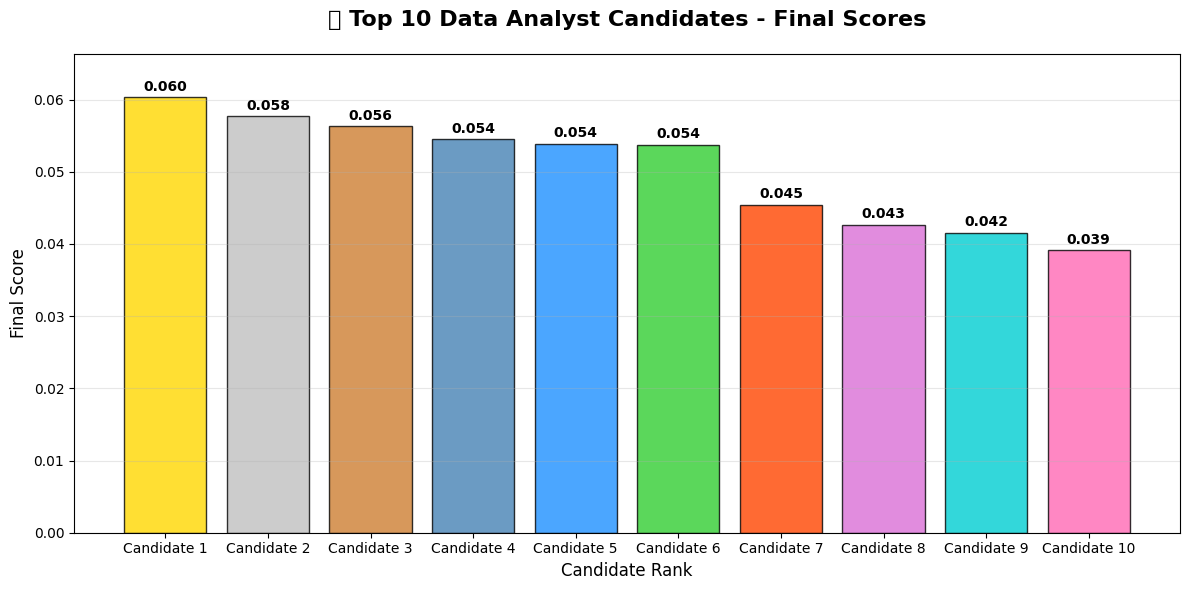

 Top candidate score: 0.060
 Processed 200 resumes across 33 categories


In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
top_scores = df_ranked.head(10)['final_score']

colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#4682B4', '#1E90FF',
          '#32CD32', '#FF4500', '#DA70D6', '#00CED1', '#FF69B4']

plt.bar(range(10), top_scores, color=colors, alpha=0.8, edgecolor='black')
plt.title('🏆 Top 10 Data Analyst Candidates - Final Scores', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Candidate Rank', fontsize=12)
plt.ylabel('Final Score', fontsize=12)
plt.xticks(range(10), [f'Candidate {i+1}' for i in range(10)], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(top_scores)*1.1)

for i, score in enumerate(top_scores):
    plt.text(i, score + 0.0005, f'{score:.3f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f" Top candidate score: {top_scores.iloc[0]:.3f}")
print(f" Processed {len(df_sample)} resumes across {df_sample['category'].nunique()} categories")


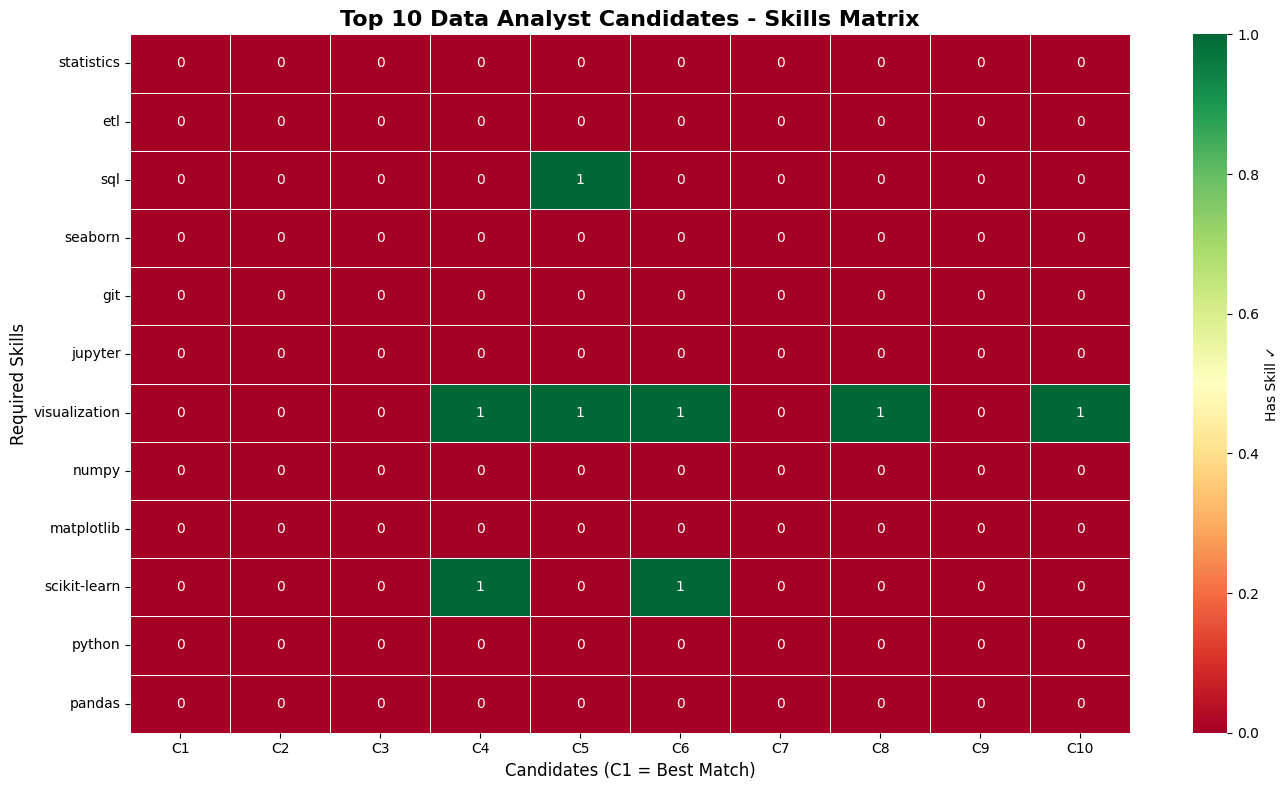


🟢 Green = Candidate HAS skill
🔴 Red = Candidate MISSING skill


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

top10 = df_ranked.head(10).copy()
skills_list = list(jd_skills)

candidate_labels = [f'C{i+1}' for i in range(len(top10))]

skill_matrix = pd.DataFrame(0, index=candidate_labels, columns=skills_list)

for idx, row in top10.iterrows():
    candidate_num = idx + 1
    candidate_skills = row['skills']
    for skill in candidate_skills:
        if skill in skills_list:
            skill_matrix.loc[f'C{candidate_num}', skill] = 1

plt.figure(figsize=(14, 8))
sns.heatmap(skill_matrix.T, annot=True, cmap='RdYlGn',
            cbar_kws={'label': 'Has Skill ✓'}, fmt='d',
            linewidths=0.5)

plt.title('Top 10 Data Analyst Candidates - Skills Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Candidates (C1 = Best Match)', fontsize=12)
plt.ylabel('Required Skills', fontsize=12)
plt.tight_layout()
plt.show()

print("\n🟢 Green = Candidate HAS skill")
print("🔴 Red = Candidate MISSING skill")
